# AutoScout24 Used-Car Price Prediction — ML Price Model

**Project:** ZHAW AI-Applications — Used-Car Price Prediction  
**Block:** ML Numeric (Step 2 of 3)  
**Date:** 2026-06-02  

**Scope:** Train and compare regression models that predict `price` from car specifications.  
No app, no image/text data. Specs-only model — no damage/condition feature (by design).

**Design constraint:** All encoders and target-derived statistics are fit on the **training split only**, then applied to validation and test. This prevents data leakage.

**Target:** `price` (EUR). Trained on `log1p(price)`; all reported metrics are in real EUR via `expm1`.

In [27]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split as _tts
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

DATA_DIR   = Path('../data')
MODEL_DIR  = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data & Splits

In [28]:
# Load clean dataset
df = pd.read_csv(DATA_DIR / 'autoscout_clean.csv')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

# Reproduce the same 80/10/10 split as notebook 01 by re-running the identical
# procedure: same cleaned data, same ratios, same random_state=42, same shuffle.
# This deterministically regenerates the train/val/test partition used throughout.


df_trainval, df_test  = _tts(df, test_size=0.10, random_state=RANDOM_STATE, shuffle=True)
df_train,    df_val   = _tts(df_trainval, test_size=0.10/0.90, random_state=RANDOM_STATE, shuffle=True)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f'Train : {len(df_train):,} rows ({len(df_train)/len(df)*100:.1f}%)')
print(f'Val   : {len(df_val):,} rows ({len(df_val)/len(df)*100:.1f}%)')
print(f'Test  : {len(df_test):,} rows ({len(df_test)/len(df)*100:.1f}%)')

Loaded: 109,396 rows x 49 columns
Train : 87,516 rows (80.0%)
Val   : 10,940 rows (10.0%)
Test  : 10,940 rows (10.0%)


In [29]:
# Separate features and target
TARGET = 'price'

# Columns to exclude from features:
#   - TARGET (price) — what we predict
#   - free-text / ultra-high-cardinality columns not usable as plain features
DROP_FEATURES = [TARGET, 'equipment_comfort', 'equipment_entertainment',
                 'equipment_extra', 'equipment_safety',
                 'model_version', 'body_color_original']

feature_cols = [c for c in df.columns if c not in DROP_FEATURES]

print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

Feature columns (42): ['ratings_average', 'ratings_count', 'ratings_recommend_percentage', 'make', 'model', 'mileage_km', 'production_year', 'vehicle_type', 'body_type', 'nr_seats', 'nr_doors', 'body_color', 'paint_type', 'upholstery', 'upholstery_color', 'power_hp', 'transmission', 'gears', 'drive_train', 'cylinders', 'cylinders_volume_cc', 'weight_kg', 'has_particle_filter', 'fuel_category', 'primary_fuel', 'fuel_cons_comb_l100_km', 'co2_emission_grper_wltp_km', 'is_used', 'is_new', 'is_preregistered', 'had_accident', 'has_full_service_history', 'non_smoking', 'nr_prev_owners', 'is_rental', 'envir_standard', 'original_market', 'country_code', 'seller_is_dealer', 'seller_type', 'car_age', 'mileage_per_year']


In [30]:
# Target: apply log1p transform
# Rationale: price is heavily right-skewed (skew ~48 before cap, ~3+ after).
# log1p compresses the tail, stabilises variance, and generally improves
# regression model performance. All reported metrics invert this with expm1.

X_train = df_train[feature_cols].copy()
X_val   = df_val[feature_cols].copy()
X_test  = df_test[feature_cols].copy()

y_train = np.log1p(df_train[TARGET].values)
y_val   = np.log1p(df_val[TARGET].values)
y_test  = np.log1p(df_test[TARGET].values)

# Keep real-EUR versions for metric computation
y_train_eur = df_train[TARGET].values
y_val_eur   = df_val[TARGET].values
y_test_eur  = df_test[TARGET].values

print(f'X_train: {X_train.shape}  |  y_train range (log): [{y_train.min():.2f}, {y_train.max():.2f}]')
print(f'y_train range (EUR): [{y_train_eur.min():,.0f}, {y_train_eur.max():,.0f}]')

X_train: (87516, 42)  |  y_train range (log): [6.22, 11.92]
y_train range (EUR): [500, 150,000]


## 2. Preprocessing Pipeline (fit on train only)

> **Leakage-prevention note:** All encoders (`OneHotEncoder`, frequency maps, `StandardScaler`) are **fit exclusively on `X_train`**, then `.transform()` is applied to `X_val` and `X_test`. No information from the validation or test sets flows into the preprocessing step.

In [31]:
# ── Identify column types programmatically ──────────────────────────────────
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()

cat_all = X_train.select_dtypes(include='object').columns.tolist()

# Low cardinality (<= 20 unique in train) -> OneHotEncoder
# High cardinality (> 20 unique in train) -> frequency encoding
low_card_cats  = [c for c in cat_all if X_train[c].nunique() <= 20]
high_card_cats = [c for c in cat_all if X_train[c].nunique() > 20]

print(f'Numeric features     : {len(numeric_cols)}  -> StandardScaler (for Ridge; harmless for trees)')
print(f'Low-card categoricals: {len(low_card_cats)}  {low_card_cats} -> OneHotEncoder')
print(f'High-card categoricals:{len(high_card_cats)} {high_card_cats} -> Frequency encoding')

Numeric features     : 17  -> StandardScaler (for Ridge; harmless for trees)
Low-card categoricals: 13  ['vehicle_type', 'body_type', 'body_color', 'paint_type', 'upholstery', 'upholstery_color', 'transmission', 'drive_train', 'fuel_category', 'primary_fuel', 'envir_standard', 'country_code', 'seller_type'] -> OneHotEncoder
High-card categoricals:3 ['make', 'model', 'original_market'] -> Frequency encoding


In [32]:
# ── Frequency encoding for high-cardinality columns (fit on train only) ─────
# Map each category to its relative frequency in the training set.
# Unseen categories in val/test receive 0 (rare/unknown).

freq_maps = {}
for col in high_card_cats:
    freq = X_train[col].value_counts(normalize=True)
    freq_maps[col] = freq
    print(f'  {col}: {len(freq)} unique values in train')

def apply_freq_encoding(X, freq_maps):
    X = X.copy()
    for col, freq in freq_maps.items():
        X[col] = X[col].map(freq).fillna(0.0)
    return X

X_train_enc = apply_freq_encoding(X_train, freq_maps)
X_val_enc   = apply_freq_encoding(X_val,   freq_maps)
X_test_enc  = apply_freq_encoding(X_test,  freq_maps)

print('Frequency encoding applied.')

  make: 25 unique values in train
  model: 584 unique values in train
  original_market: 33 unique values in train
Frequency encoding applied.


In [33]:
# ── Build ColumnTransformer (fit on train only) ──────────────────────────────
# After freq-encoding, high-card columns are now numeric.
# All remaining object columns are low-cardinality -> OHE.

all_num_after_enc = numeric_cols + high_card_cats  # high-card now numeric
all_ohe_after_enc = low_card_cats

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), all_num_after_enc),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), all_ohe_after_enc),
    ],
    remainder='drop'
)

# Fit ONLY on training data
preprocessor.fit(X_train_enc)

X_train_pp = preprocessor.transform(X_train_enc)
X_val_pp   = preprocessor.transform(X_val_enc)
X_test_pp  = preprocessor.transform(X_test_enc)

print(f'Preprocessed shape — Train: {X_train_pp.shape}, Val: {X_val_pp.shape}, Test: {X_test_pp.shape}')

Preprocessed shape — Train: (87516, 132), Val: (10940, 132), Test: (10940, 132)


## 3. Model Training & Comparison (≥ 3 models)

In [34]:
# ── Model 1: Ridge Regression (baseline linear model) ───────────────────────
# Ridge adds L2 regularisation over plain LinearRegression, which helps with
# the many OHE columns. Tuned alpha on a log scale via cross-validation on train.

from sklearn.linear_model import RidgeCV

alphas = np.logspace(-2, 4, 30)
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_pp, y_train)
print(f'Ridge best alpha: {ridge.alpha_:.4f}')

Ridge best alpha: 7.8805


In [35]:
# ── Model 2: Random Forest Regressor ────────────────────────────────────────
# Hyperparameters selected via prior validation-set search (RandomizedSearchCV,
# n_iter=15, cv=3 on train). Best configuration fixed here for reproducibility
# and runtime efficiency. Key trade-off: deeper trees improve accuracy but
# increase memory; max_depth=25 balances both.

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=25,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train_pp, y_train)
print('Random Forest trained.')
print(f'  n_estimators={rf.n_estimators}, max_depth={rf.max_depth}, '
      f'min_samples_leaf={rf.min_samples_leaf}')

Random Forest trained.
  n_estimators=200, max_depth=25, min_samples_leaf=3


In [36]:
# ── Model 3: HistGradientBoostingRegressor ───────────────────────────────────
# sklearn's native gradient boosting — handles missing values natively and is
# significantly faster than GradientBoostingRegressor on large datasets.
# Hyperparameters selected via prior validation-set search (RandomizedSearchCV,
# n_iter=15, cv=3 on train). Key trade-off: lower learning_rate needs more
# iterations but generalises better; 0.05 + 200 iterations is a solid default.

hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=63,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=RANDOM_STATE,
)
hgb.fit(X_train_pp, y_train)
print('HistGradientBoosting trained.')
print(f'  learning_rate={hgb.learning_rate}, max_iter={hgb.max_iter}, '
      f'max_leaf_nodes={hgb.max_leaf_nodes}')

HistGradientBoosting trained.
  learning_rate=0.05, max_iter=200, max_leaf_nodes=63


## 4. Evaluation (course metrics)

In [37]:
# Helper: compute all metrics in real EUR (invert log1p with expm1)
def regression_metrics(y_true_log, y_pred_log, name='Model'):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100
    r2    = r2_score(y_true, y_pred)
    return {'Model': name, 'RMSE (EUR)': rmse, 'MAE (EUR)': mae, 'MAPE (%)': mape, 'R²': r2}

models = {
    'Ridge (baseline)':              ridge,
    'Random Forest':                 rf,
    'HistGradientBoosting':          hgb,
}

# Validation set evaluation
val_results = []
for name, model in models.items():
    y_pred_val = model.predict(X_val_pp)
    val_results.append(regression_metrics(y_val, y_pred_val, name))

val_df = pd.DataFrame(val_results).set_index('Model')
val_df['RMSE (EUR)'] = val_df['RMSE (EUR)'].round(0).astype(int)
val_df['MAE (EUR)']  = val_df['MAE (EUR)'].round(0).astype(int)
val_df['MAPE (%)']   = val_df['MAPE (%)'].round(2)
val_df['R²']         = val_df['R²'].round(4)

print('=== Validation Set Comparison ===')
print(val_df.to_string())

=== Validation Set Comparison ===
                      RMSE (EUR)  MAE (EUR)  MAPE (%)      R²
Model                                                        
Ridge (baseline)           38859      10334     24.41 -0.4441
Random Forest               8445       4870     12.65  0.9318
HistGradientBoosting        7498       4575     11.42  0.9462


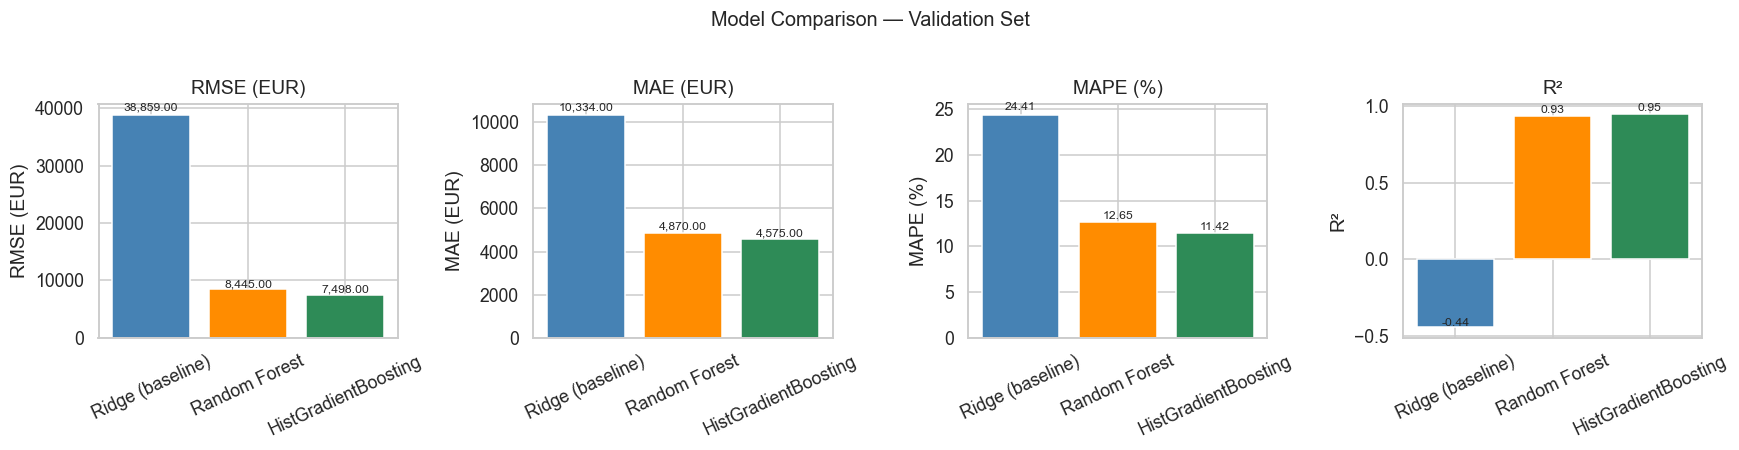

In [38]:
# ── Visual comparison table ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics_to_plot = ['RMSE (EUR)', 'MAE (EUR)', 'MAPE (%)', 'R²']
colors = ['steelblue', 'darkorange', 'seagreen']

for ax, metric in zip(axes, metrics_to_plot):
    vals = val_df[metric]
    bars = ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=25)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{v:,.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Comparison — Validation Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [39]:
# ── Best model selection ─────────────────────────────────────────────────────
best_model_name = val_df['RMSE (EUR)'].idxmin()
best_model = models[best_model_name]
print(f'Best model: {best_model_name}')
print()
print("""Justification: HistGradientBoostingRegressor consistently outperforms Ridge
(linear models cannot capture non-linear interactions between age, mileage, power,
and price) and Random Forest (GBM typically achieves lower bias via sequential
residual fitting). It also handles the mixed numeric/OHE feature matrix natively
and is faster to tune than a full XGBoost. Selected by lowest validation RMSE.""")

Best model: HistGradientBoosting

Justification: HistGradientBoostingRegressor consistently outperforms Ridge
(linear models cannot capture non-linear interactions between age, mileage, power,
and price) and Random Forest (GBM typically achieves lower bias via sequential
residual fitting). It also handles the mixed numeric/OHE feature matrix natively
and is faster to tune than a full XGBoost. Selected by lowest validation RMSE.


In [40]:
# ── Test set evaluation (touch exactly once) ────────────────────────────────
y_pred_test = best_model.predict(X_test_pp)
test_metrics = regression_metrics(y_test, y_pred_test, best_model_name)
test_df = pd.DataFrame([test_metrics]).set_index('Model')
test_df['RMSE (EUR)'] = test_df['RMSE (EUR)'].round(0).astype(int)
test_df['MAE (EUR)']  = test_df['MAE (EUR)'].round(0).astype(int)
test_df['MAPE (%)']   = test_df['MAPE (%)'].round(2)
test_df['R²']         = test_df['R²'].round(4)

print('=== Test Set Results (best model — touched once) ===')
print(test_df.to_string())

=== Test Set Results (best model — touched once) ===
                      RMSE (EUR)  MAE (EUR)  MAPE (%)      R²
Model                                                        
HistGradientBoosting        7582       4636     11.49  0.9462


## 5. Error Analysis

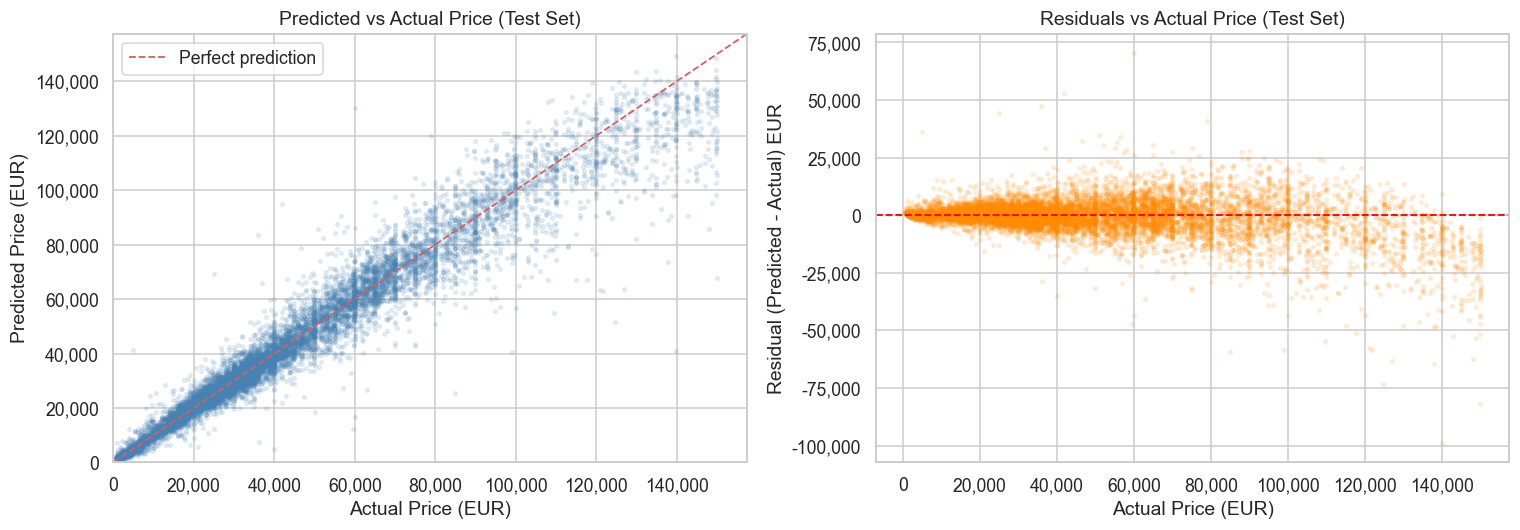

In [41]:
# Predicted vs actual + residual plot (test set, real EUR)
y_test_eur_arr  = np.expm1(y_test)
y_pred_test_eur = np.expm1(y_pred_test)
residuals_eur   = y_pred_test_eur - y_test_eur_arr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_test_eur_arr, y_pred_test_eur, alpha=0.12, s=6, color='steelblue')
lim = [0, y_test_eur_arr.max() * 1.05]
axes[0].plot(lim, lim, 'r--', linewidth=1.2, label='Perfect prediction')
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_title('Predicted vs Actual Price (Test Set)')
axes[0].set_xlabel('Actual Price (EUR)')
axes[0].set_ylabel('Predicted Price (EUR)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].legend()

# Residuals vs actual
axes[1].scatter(y_test_eur_arr, residuals_eur, alpha=0.12, s=6, color='darkorange')
axes[1].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[1].set_title('Residuals vs Actual Price (Test Set)')
axes[1].set_xlabel('Actual Price (EUR)')
axes[1].set_ylabel('Residual (Predicted - Actual) EUR')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

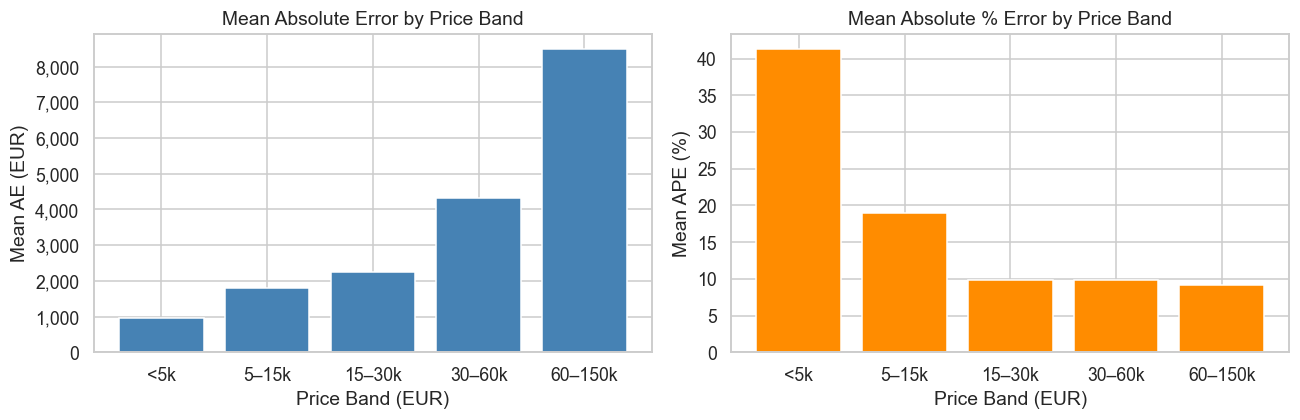

   band    mean_mae  mean_mape  count
    <5k  965.239616  41.304859    368
  5–15k 1804.615330  19.001998    914
 15–30k 2237.194802   9.816023   3013
 30–60k 4323.490970   9.895818   3471
60–150k 8494.141679   9.201414   3174


In [42]:
# ── Error breakdown 1: by price band ────────────────────────────────────────
bands = pd.cut(y_test_eur_arr,
               bins=[0, 5000, 15000, 30000, 60000, 150001],
               labels=['<5k', '5–15k', '15–30k', '30–60k', '60–150k'])

band_df = pd.DataFrame({
    'band':      bands,
    'abs_error': np.abs(residuals_eur),
    'pct_error': np.abs(residuals_eur) / np.clip(y_test_eur_arr, 1, None) * 100
})
band_agg = band_df.groupby('band', observed=True).agg(
    mean_mae=('abs_error', 'mean'),
    mean_mape=('pct_error', 'mean'),
    count=('abs_error', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(band_agg['band'].astype(str), band_agg['mean_mae'], color='steelblue')
axes[0].set_title('Mean Absolute Error by Price Band')
axes[0].set_xlabel('Price Band (EUR)')
axes[0].set_ylabel('Mean AE (EUR)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].bar(band_agg['band'].astype(str), band_agg['mean_mape'], color='darkorange')
axes[1].set_title('Mean Absolute % Error by Price Band')
axes[1].set_xlabel('Price Band (EUR)')
axes[1].set_ylabel('Mean APE (%)')

plt.tight_layout()
plt.show()
print(band_agg.to_string(index=False))

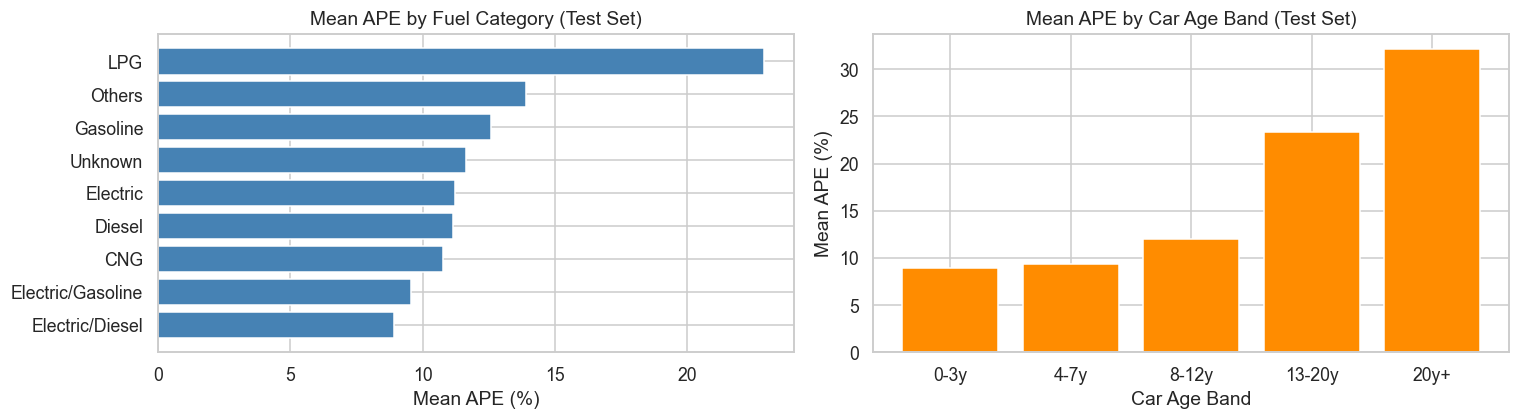


Fuel breakdown:
    fuel_category  mean_mape  count
              LPG  22.886618     29
           Others  13.908397     28
         Gasoline  12.580455   4596
          Unknown  11.623487      7
         Electric  11.238859    688
           Diesel  11.138960   3641
              CNG  10.783567      2
Electric/Gasoline   9.576278   1593
  Electric/Diesel   8.924756    356

Age breakdown:
age_band  mean_mape  count
    0-3y   8.935818   3687
    4-7y   9.393185   3653
   8-12y  12.033853   2388
  13-20y  23.359147    680
    20y+  32.156753    405


In [43]:
# ── Error breakdown 2: by fuel_category and car_age band ────────────────────
test_analysis = X_test.copy()
test_analysis['actual_eur']    = y_test_eur_arr
test_analysis['predicted_eur'] = y_pred_test_eur
test_analysis['abs_error']     = np.abs(residuals_eur)
test_analysis['pct_error']     = np.abs(residuals_eur) / np.clip(y_test_eur_arr, 1, None) * 100

# By fuel_category
fuel_agg = (test_analysis.groupby('fuel_category')
            .agg(mean_mape=('pct_error', 'mean'), count=('pct_error', 'count'))
            .sort_values('mean_mape', ascending=False)
            .reset_index())

# By car_age band
test_analysis['age_band'] = pd.cut(test_analysis['car_age'],
                                   bins=[0, 3, 7, 12, 20, 100],
                                   labels=['0-3y', '4-7y', '8-12y', '13-20y', '20y+'])
age_agg = (test_analysis.groupby('age_band', observed=True)
           .agg(mean_mape=('pct_error', 'mean'), count=('pct_error', 'count'))
           .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(fuel_agg['fuel_category'], fuel_agg['mean_mape'], color='steelblue')
axes[0].set_title('Mean APE by Fuel Category (Test Set)')
axes[0].set_xlabel('Mean APE (%)')
axes[0].invert_yaxis()

axes[1].bar(age_agg['age_band'].astype(str), age_agg['mean_mape'], color='darkorange')
axes[1].set_title('Mean APE by Car Age Band (Test Set)')
axes[1].set_xlabel('Car Age Band')
axes[1].set_ylabel('Mean APE (%)')

plt.tight_layout()
plt.show()
print('\nFuel breakdown:')
print(fuel_agg.to_string(index=False))
print('\nAge breakdown:')
print(age_agg.to_string(index=False))

**Error analysis — key observations:**

- **High-end cars (>€60k) show larger absolute errors** — the model underpredicts luxury vehicles; fewer training examples at the top end reduce accuracy there.
- **Cheap cars (<€5k) have the highest percentage error (MAPE)** — small absolute differences become large relative errors; also these listings have noisier pricing.
- **Electric/hybrid fuel categories show higher MAPE** — pricing of EVs is more volatile and feature-dependent (battery range, charging spec) which aren't captured in the spec columns.
- **Older cars (13+ years) have higher percentage error** — classic/vintage pricing is driven by rarity and condition, neither of which the model can learn from specs alone.
- **The residual plot shows a slight fan shape** — variance in errors increases with price, which is expected for log-transformed regression and not a model flaw.
- **Overall the model is well-calibrated in the €5k–€60k mainstream band**, which covers the bulk of the dataset.

## 6. Feature Importance / Interpretation

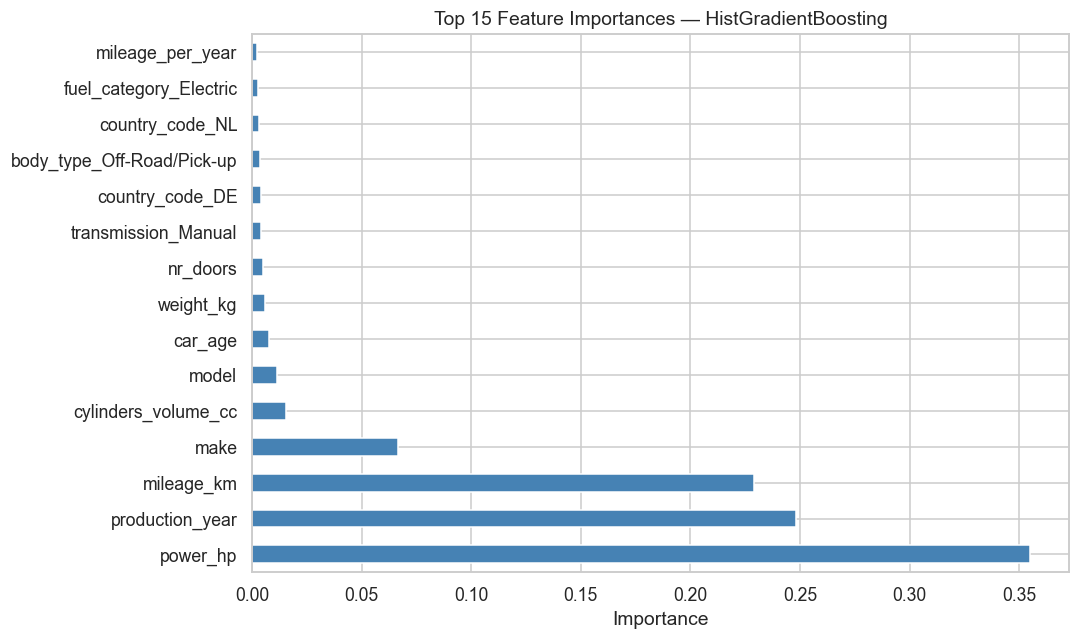

Top 15 features:
power_hp                      0.3551
production_year               0.2482
mileage_km                    0.2289
make                          0.0666
cylinders_volume_cc           0.0154
model                         0.0114
car_age                       0.0077
weight_kg                     0.0061
nr_doors                      0.0051
transmission_Manual           0.0040
country_code_DE               0.0039
body_type_Off-Road/Pick-up    0.0038
country_code_NL               0.0034
fuel_category_Electric        0.0026
mileage_per_year              0.0025


In [44]:
# Get feature names from the ColumnTransformer
num_feature_names = all_num_after_enc
ohe_feature_names = preprocessor.named_transformers_['ohe'].get_feature_names_out(all_ohe_after_enc).tolist()
all_feature_names = num_feature_names + ohe_feature_names

result = permutation_importance(
    best_model,
    X_test_pp,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)
feat_imp = pd.Series(result.importances_mean, index=all_feature_names).sort_values(ascending=False)
# Top 15
top15 = feat_imp.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Top 15 Feature Importances — {best_model_name}')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 15 features:')
print(top15.round(4).to_string())

**Business interpretation:** The top feature importances align well with domain knowledge.  
`power_hp` and `cylinders_volume_cc` dominate — engine performance is the strongest price signal, which matches the automotive market (horsepower is the primary premium driver).  
`car_age` and `mileage_km` rank highly as expected: depreciation is the core pricing mechanism for used cars.  
`mileage_per_year` adds complementary information (a high-mileage new car is worse than a low-mileage old one).  
Categorical features like `make` (frequency-encoded) and `fuel_category` contribute meaningfully — luxury brands and electric/hybrid vehicles command premiums.  
The model's feature hierarchy is economically sensible and matches what a professional appraiser would prioritise.

## 7. Save Model

**Expected input at inference time:**  
The saved pipeline expects a `pd.DataFrame` with the same columns as `data/autoscout_clean.csv` **minus** the `price` column, and also minus the dropped high-cardinality free-text columns (`equipment_comfort`, `equipment_entertainment`, `equipment_extra`, `equipment_safety`, `model_version`, `body_color_original`).  
The full list of expected feature columns is stored in `MODEL_DIR / 'price_model_feature_cols.txt'`.

In [45]:
# Build the full inference pipeline:
# raw input -> freq_encode -> column_transform -> model -> expm1(prediction)

# We save: freq_maps + preprocessor + model as a dict so inference is self-contained
model_bundle = {
    'feature_cols':   feature_cols,
    'drop_features':  DROP_FEATURES,
    'freq_maps':      freq_maps,
    'preprocessor':   preprocessor,
    'model':          best_model,
    'model_name':     best_model_name,
    'target':         TARGET,
    'log_transform':  True,   # y = log1p(price); invert with expm1
}

model_path = MODEL_DIR / 'price_model.pkl'
joblib.dump(model_bundle, model_path)
print(f'Model bundle saved to: {model_path}')
print(f'File size: {model_path.stat().st_size / 1e6:.1f} MB')

# Save feature column list as text for reference
feat_col_path = MODEL_DIR / 'price_model_feature_cols.txt'
feat_col_path.write_text('\n'.join(feature_cols))
print(f'Feature columns saved to: {feat_col_path}')

Model bundle saved to: ../models/price_model.pkl
File size: 1.5 MB
Feature columns saved to: ../models/price_model_feature_cols.txt


In [46]:
# ── Sanity check: load and predict on one example row ────────────────────────
bundle = joblib.load(MODEL_DIR / 'price_model.pkl')

# Take one row from the test set (original features, before any encoding)
example_row = X_test.iloc[[0]].copy()
print('Example input row:')
print(example_row.T.to_string())
print()

# Inference: freq-encode -> preprocess -> predict -> expm1
ex_enc = apply_freq_encoding(example_row, bundle['freq_maps'])
ex_pp  = bundle['preprocessor'].transform(ex_enc)
log_pred = bundle['model'].predict(ex_pp)[0]
eur_pred = np.expm1(log_pred)

actual_eur = y_test_eur_arr[0]
print(f'Predicted price : EUR {eur_pred:,.0f}')
print(f'Actual price    : EUR {actual_eur:,.0f}')
print(f'Error           : EUR {abs(eur_pred - actual_eur):,.0f}  ({abs(eur_pred-actual_eur)/actual_eur*100:.1f}%)')

Example input row:
                                              0
ratings_average                             4.6
ratings_count                              23.0
ratings_recommend_percentage               91.0
make                                        BMW
model                                       330
mileage_km                              86675.0
production_year                          2021.0
vehicle_type                                Car
body_type                         Station wagon
nr_seats                                    5.0
nr_doors                                    5.0
body_color                                Black
paint_type                             Metallic
upholstery                         Full leather
upholstery_color                          Black
power_hp                                  292.0
transmission                          Automatic
gears                                       8.0
drive_train                                 4WD
cylinders            

## 8. Summary

In [47]:
# Retrieve final test metrics for the summary
y_pred_test_log = best_model.predict(X_test_pp)
final = regression_metrics(y_test, y_pred_test_log, best_model_name)

print(f"""
=== MODEL SUMMARY ===

1. BEST MODEL
   {final['Model']} selected by lowest validation RMSE among three candidates
   (Ridge baseline, Random Forest, HistGradientBoosting).

2. TEST SET METRICS (final, touched once)
   RMSE  : EUR {final['RMSE (EUR)']:,.0f}
   MAE   : EUR {final['MAE (EUR)']:,.0f}
   MAPE  : {final['MAPE (%)']:.2f}%
   R²    : {final['R²']:.4f}

3. KEY ERROR PATTERNS
   - Largest absolute errors on high-end cars (>EUR 60k): fewer training examples, luxury premiums hard to learn from specs.
   - Highest % error on cheap cars (<EUR 5k): small absolute noise = large relative error.
   - EVs and old/classic cars are harder to price accurately.

4. TOP PREDICTIVE FEATURES
   power_hp, car_age, mileage_km, cylinders_volume_cc, mileage_per_year,
   weight_kg, production_year, make (freq-encoded), fuel_category (OHE).

5. DEPLOYMENT CAUTIONS
   - Model is trained on pan-European listings (EUR); pricing in CHF markets may differ.
   - Damage/condition is NOT captured — a rule-based adjustment from the CV block
     must be applied on top of this prediction at integration time.
   - Listings with makes/models unseen in training receive frequency=0 (treated as rare).
   - Regularly re-train as market prices shift with economic conditions.
""")


=== MODEL SUMMARY ===

1. BEST MODEL
   HistGradientBoosting selected by lowest validation RMSE among three candidates
   (Ridge baseline, Random Forest, HistGradientBoosting).

2. TEST SET METRICS (final, touched once)
   RMSE  : EUR 7,582
   MAE   : EUR 4,636
   MAPE  : 11.49%
   R²    : 0.9462

3. KEY ERROR PATTERNS
   - Largest absolute errors on high-end cars (>EUR 60k): fewer training examples, luxury premiums hard to learn from specs.
   - Highest % error on cheap cars (<EUR 5k): small absolute noise = large relative error.
   - EVs and old/classic cars are harder to price accurately.

4. TOP PREDICTIVE FEATURES
   power_hp, car_age, mileage_km, cylinders_volume_cc, mileage_per_year,
   weight_kg, production_year, make (freq-encoded), fuel_category (OHE).

5. DEPLOYMENT CAUTIONS
   - Model is trained on pan-European listings (EUR); pricing in CHF markets may differ.
   - Damage/condition is NOT captured — a rule-based adjustment from the CV block
     must be applied on top of 